# Model 5 — K-Nearest Neighbours (KNN)
**Student:** IT25101431 — Nasik.F.M  
**Dataset:** Online Shoppers Purchasing Intention  
**Task:** Binary classification — predict `Revenue` (purchase = 1, no purchase = 0)

KNN is an **instance-based (lazy) learner**. It does not learn weights during training — it simply stores the training data. To classify a new session, it finds the **k most similar sessions** (nearest neighbours by distance) and predicts the majority class among them. The predicted probability is the (weighted) share of buyers among the k neighbours.
- `n_neighbors` (k): small k = flexible but noisy; large k = smoother but may miss local patterns.
- `weights`: `uniform` (every neighbour counts equally) or `distance` (closer neighbours count more).
- `p`: distance metric — 1 = Manhattan, 2 = Euclidean.

Because KNN is entirely **distance-based**, how the features are transformed and scaled has a huge effect on its performance.

## 1. Import libraries

In [1]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

RANDOM_STATE = 42
BASE = ".." if os.path.exists("../data/raw/online_shoppers_intention.csv") else "."
DATA_PATH = f"{BASE}/data/raw/online_shoppers_intention.csv"
FIG_DIR = f"{BASE}/results/model_visualizations"
OUT_DIR = f"{BASE}/results/outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load the dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df["Revenue"].value_counts(normalize=True).round(3))
df.head()

(12330, 18)
Revenue
False    0.845
True     0.155
Name: proportion, dtype: float64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Prepare features and target
Same features and same train/test split (`random_state=42`) as the previous models, so results are directly comparable.

In [3]:
df["Weekend"] = df["Weekend"].astype(int)
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"])

categorical_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

## 4. Train / test split (stratified 80 / 20)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(9864, 17) (2466, 17)


## 5. Why preprocessing matters for KNN
The numeric features are **heavily right-skewed** (most sessions have small values, a few have very large values). With plain standardisation, those extreme values dominate the distance calculation.

ProductRelated_Duration    8.01
Informational_Duration     7.70
PageValues                 6.19
Administrative_Duration    5.68
ProductRelated             4.37
Informational              4.14
SpecialDay                 3.26
BounceRates                2.92
ExitRates                  2.13
Administrative             1.97
Weekend                    1.27
dtype: float64


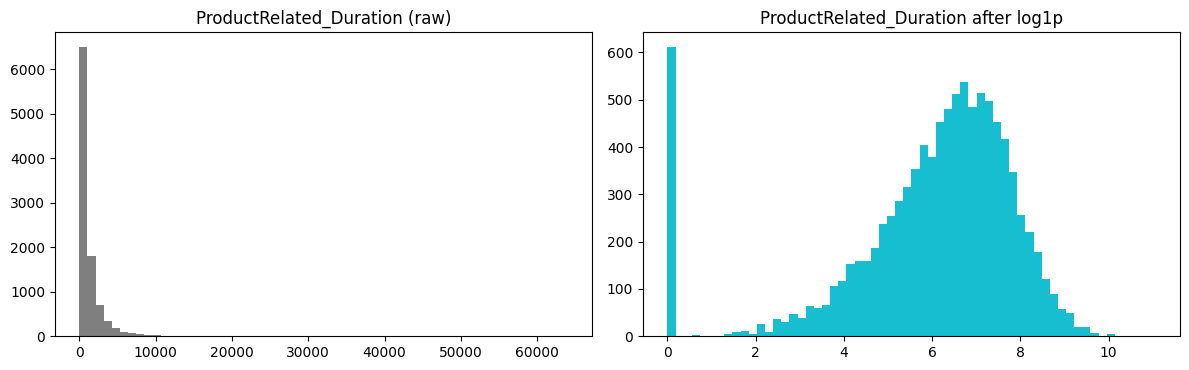

In [5]:
print(X_train[numeric_cols].skew().round(2).sort_values(ascending=False))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(X_train["ProductRelated_Duration"], bins=60, color="tab:gray")
ax[0].set_title("ProductRelated_Duration (raw)")
ax[1].hist(np.log1p(X_train["ProductRelated_Duration"]), bins=60, color="tab:cyan")
ax[1].set_title("ProductRelated_Duration after log1p")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/knn_01_skew.png", dpi=150, bbox_inches="tight")
plt.show()

We compare three preprocessing options with 5-fold CV on the training set (k = 25, distance weights):
1. **Standard scaling + all categoricals one-hot** (same as SVM / MLP)
2. **log1p + scaling + all categoricals one-hot**
3. **log1p + scaling + only `Month` and `VisitorType` one-hot** — `OperatingSystems`, `Browser`, `Region` and `TrafficType` are ID codes that add ~50 extra one-hot dimensions, which dilutes the distances (curse of dimensionality).

In [6]:
log_scale = make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler())
options = {
    "1. Standard + all categoricals": ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)]),
    "2. log1p + all categoricals": ColumnTransformer([
        ("num", log_scale, numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)]),
    "3. log1p + Month/VisitorType only": ColumnTransformer([
        ("num", log_scale, numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Month", "VisitorType"])]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, prep in options.items():
    m = Pipeline([("prep", prep), ("model", KNeighborsClassifier(n_neighbors=25, weights="distance"))])
    prob = cross_val_predict(m, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    rows.append({"Preprocessing": name, "CV ROC-AUC": roc_auc_score(y_train, prob),
                 "CV F1 (threshold 0.5)": f1_score(y_train, prob >= 0.5),
                 "Features": prep.fit_transform(X_train).shape[1]})
prep_cmp = pd.DataFrame(rows).set_index("Preprocessing").round(4)
prep_cmp

,CV ROC-AUC,CV F1 (threshold 0.5),Features
Preprocessing,,,
1. Standard + all categoricals,0.8581,0.4474,74
2. log1p + all categoricals,0.9115,0.6120,74
3. log1p + Month/VisitorType only,0.9157,0.6248,24


Log-transforming the skewed features gives a large improvement, and dropping the ID-code categoricals helps further while using far fewer dimensions. **Option 3 is used for the final model.**

In [7]:
preprocess = options["3. log1p + Month/VisitorType only"]

## 6. Baseline model (default KNN: k = 5, uniform weights, plain standard scaling)

In [8]:
baseline = Pipeline([("prep", options["1. Standard + all categoricals"]), ("model", KNeighborsClassifier())])
baseline.fit(X_train, y_train)
yb = baseline.predict(X_test)
print("Baseline accuracy:", round(accuracy_score(y_test, yb), 4))
print("Baseline recall  :", round(recall_score(y_test, yb), 4))
print("Baseline F1      :", round(f1_score(y_test, yb), 4))

Baseline accuracy: 0.8759
Baseline recall  : 0.3691
Baseline F1      : 0.4796


## 7. Hyperparameter tuning with GridSearchCV (5-fold stratified CV, scoring = ROC-AUC)
KNN has no `class_weight` option, so we tune for **ROC-AUC** (how well it ranks buyers above non-buyers) and handle the imbalance afterwards by choosing a lower decision threshold (step 8).

In [9]:
pipe = Pipeline([("prep", preprocess), ("model", KNeighborsClassifier())])
param_grid = {
    "model__n_neighbors": [5, 11, 21, 31, 41, 51, 71, 101],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params :", grid.best_params_)
print("Best CV AUC :", round(grid.best_score_, 4))
best_model = grid.best_estimator_

Best params : {'model__n_neighbors': 71, 'model__p': 1, 'model__weights': 'distance'}
Best CV AUC : 0.9241


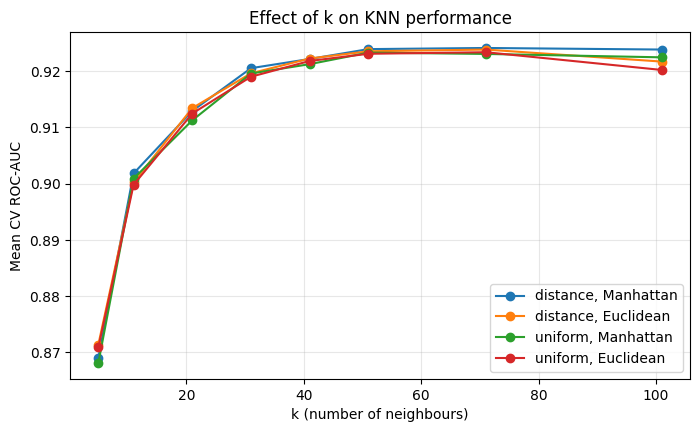

In [10]:
res = pd.DataFrame(grid.cv_results_)
plt.figure(figsize=(8, 4.5))
for (w, p), g in res.groupby(["param_model__weights", "param_model__p"]):
    label = f"{w}, {'Manhattan' if p == 1 else 'Euclidean'}"
    plt.plot(g["param_model__n_neighbors"], g["mean_test_score"], marker="o", label=label)
plt.xlabel("k (number of neighbours)")
plt.ylabel("Mean CV ROC-AUC")
plt.title("Effect of k on KNN performance")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/knn_02_k_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Choosing the decision threshold (on training data only)
Because only ~15% of neighbours are usually buyers, a 0.5 threshold misses many buyers. We use **out-of-fold predictions on the training set** to find the threshold that maximises F1, then apply that fixed threshold to the test set. The test set is not used for this choice, so there is no leakage.

Chosen threshold (max CV F1): 0.35


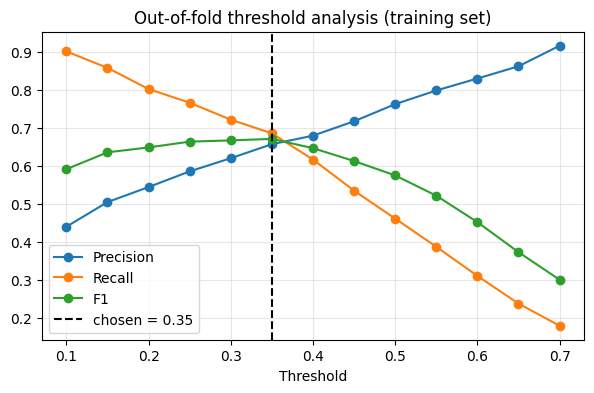

,Threshold,Precision,Recall,F1
0,0.10,0.441,0.902,0.592
1,0.15,0.505,0.858,0.636
2,0.20,0.545,0.803,0.649
3,0.25,0.586,0.767,0.664
4,0.30,0.621,0.722,0.668
5,0.35,0.658,0.686,0.672
6,0.40,0.680,0.617,0.647
7,0.45,0.718,0.535,0.613
8,0.50,0.763,0.462,0.576
9,0.55,0.799,0.388,0.522


In [11]:
oof_prob = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
th = np.round(np.arange(0.10, 0.71, 0.05), 2)
th_rows = [(t, precision_score(y_train, oof_prob >= t, zero_division=0),
            recall_score(y_train, oof_prob >= t), f1_score(y_train, oof_prob >= t)) for t in th]
th_train = pd.DataFrame(th_rows, columns=["Threshold", "Precision", "Recall", "F1"])
BEST_T = float(th_train.loc[th_train["F1"].idxmax(), "Threshold"])
print("Chosen threshold (max CV F1):", BEST_T)

th_train.plot(x="Threshold", figsize=(7, 4), marker="o")
plt.axvline(BEST_T, color="k", linestyle="--", label=f"chosen = {BEST_T}")
plt.title("Out-of-fold threshold analysis (training set)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/knn_03_threshold.png", dpi=150, bbox_inches="tight")
plt.show()
th_train.round(3)

## 9. Evaluate on the test set

In [12]:
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)
y_pred = (y_prob >= BEST_T).astype(int)

print("At default threshold 0.5 -> Recall %.4f, F1 %.4f" % (recall_score(y_test, y_pred_05), f1_score(y_test, y_pred_05)))
print(f"At chosen threshold {BEST_T} ->")
results = {
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
}
print(pd.Series(results).drop("Model").astype(float).round(4))
print()
print(classification_report(y_test, y_pred, target_names=["No purchase", "Purchase"]))

At default threshold 0.5 -> Recall 0.4555, F1 0.5622
At chosen threshold 0.35 ->
Accuracy     0.8901
Precision    0.6419
Recall       0.6571
F1           0.6494
ROC_AUC      0.9145
dtype: float64

              precision    recall  f1-score   support

 No purchase       0.94      0.93      0.93      2084
    Purchase       0.64      0.66      0.65       382

    accuracy                           0.89      2466
   macro avg       0.79      0.79      0.79      2466
weighted avg       0.89      0.89      0.89      2466



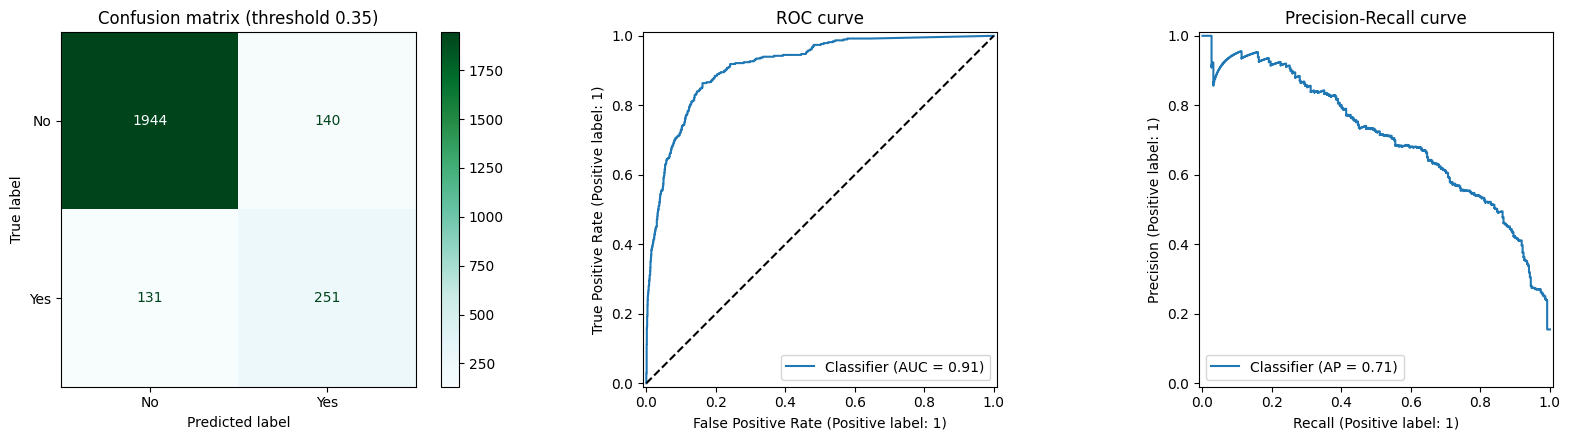

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No", "Yes"], cmap="BuGn", ax=ax[0])
ax[0].set_title(f"Confusion matrix (threshold {BEST_T})")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
ax[2].set_title("Precision-Recall curve")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/knn_04_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Feature importance (permutation)
KNN has no coefficients or feature importances, so we use **permutation importance**: how much the test ROC-AUC drops when each feature is shuffled.

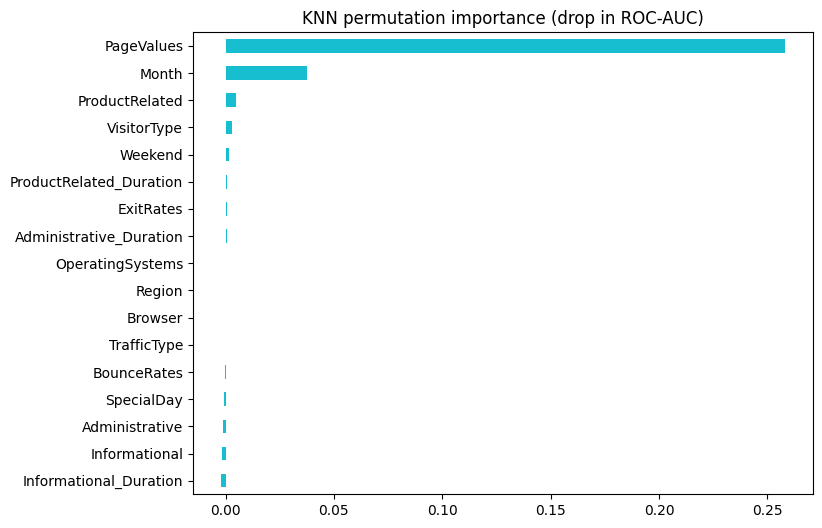

PageValues                 0.2581
Month                      0.0374
ProductRelated             0.0049
VisitorType                0.0031
Weekend                    0.0017
ProductRelated_Duration    0.0008
ExitRates                  0.0008
Administrative_Duration    0.0006
TrafficType                0.0000
Region                     0.0000
dtype: float64

In [14]:
perm = permutation_importance(best_model, X_test, y_test, scoring="roc_auc", n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
perm_imp.sort_values().plot.barh(color="tab:cyan")
plt.title("KNN permutation importance (drop in ROC-AUC)")
plt.savefig(f"{FIG_DIR}/knn_05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
perm_imp.round(4).head(10)

Features with zero importance (`OperatingSystems`, `Browser`, `Region`, `TrafficType`) are not used by this model because they were excluded in preprocessing option 3.

## 11. Comparison with the previous models

In [15]:
files = sorted(glob.glob(f"{OUT_DIR}/model_results_*.csv"))
comp = pd.concat([pd.read_csv(f) for f in files if not f.endswith("_knn.csv")] + [pd.DataFrame([results])],
                 ignore_index=True)
comp = comp.set_index("Model").astype(float).round(4)
comp

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.8719,0.5673,0.7277,0.6376,0.8965
MLP Neural Network,0.8354,0.4819,0.8377,0.6119,0.9150
Random Forest,0.8909,0.6348,0.6963,0.6642,0.9197
SVM (RBF),0.8727,0.5685,0.7382,0.6424,0.9025
KNN,0.8901,0.6419,0.6571,0.6494,0.9145


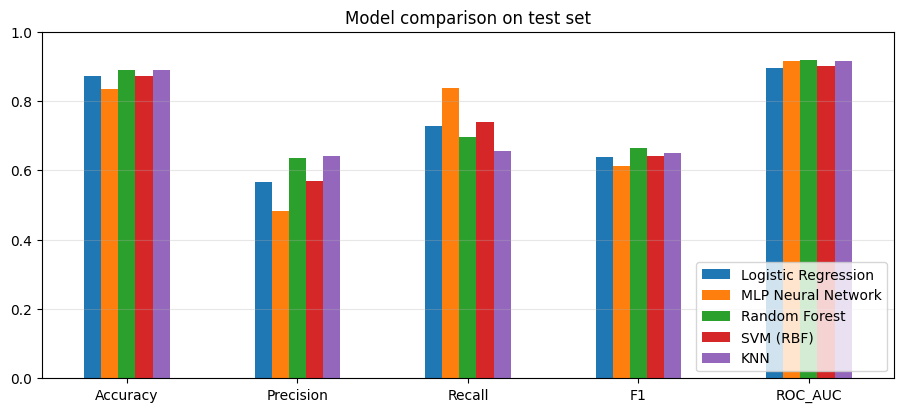

In [16]:
comp.T.plot.bar(figsize=(11, 4.5), rot=0)
plt.ylim(0, 1)
plt.title("Model comparison on test set")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.savefig(f"{FIG_DIR}/knn_06_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Save the model and results
The chosen threshold is saved with the model, because KNN's `predict()` always uses 0.5.

In [17]:
joblib.dump({"model": best_model, "threshold": BEST_T}, f"{OUT_DIR}/knn_model.pkl", compress=3)
pd.DataFrame([results]).to_csv(f"{OUT_DIR}/model_results_knn.csv", index=False)
print("Saved model and results.")

Saved model and results.


## 13. Conclusion
- Preprocessing was the key to KNN: log-transforming the skewed features and dropping the ID-code categoricals raised CV ROC-AUC from 0.858 to 0.916 and cut the feature space from 74 to 24 dimensions.
- Tuned settings: **k = 71, distance-weighted, Manhattan distance (p = 1)**, with a decision threshold of **0.35** chosen from out-of-fold training predictions.
- Test results: **Accuracy 0.890, Precision 0.642, Recall 0.657, F1 0.649, ROC-AUC 0.915**.
- Compared with the default KNN (k = 5, standard scaling: F1 0.480, recall 0.369), the tuned model is far better. It now has the **highest precision of all models** (0.642) and is second only to Random Forest on F1 and accuracy.
- `PageValues` and `Month` are again the most important features.
- Drawbacks: KNN stores the whole training set and computes distances at prediction time, so predictions are slower than other models on large data, and it needs careful feature engineering and threshold tuning to handle the class imbalance.